## Nurislam Aliyev

### Course: Deep Learning

### ID: 24B030024

### Instructor: Senior-Lecturer, Aidyn Abirov

#### Homework 3


### Task 1

In [2]:
import numpy as np
X = np.array([[1., 0.], [0., 1.], [1., 1.]])
y = np.array([[1.], [2.], [1.]])
W1 = np.array([[1., -1.], [-1., 1.]])
b1 = np.array([0.5, 0.5])
W2 = np.array([[1.], [2.]])
b2 = np.array([0.])



Z1 = X @ W1 + b1
H = np.maximum(0, Z1)
Yhat = H @ W2 + b2

for name, a in [("X", X), ("y", y), ("W1", W1), ("b1", b1), ("Z1", Z1),
                ("H", H), ("W2", W2), ("b2", b2), ("Yhat", Yhat)]:
    print(f"{name:5s} {a.shape}")

assert Yhat.shape == y.shape # (3,1) - (3,) would silently broadcast to (3,3)

residuals = Yhat - y
squared_errs = residuals ** 2
mse = squared_errs.mean()


print("Z1 =\n", Z1)
print("H =\n", H)
print("Yhat =", Yhat.ravel())
print("squared errors =", squared_errs.ravel())
print("MSE =", mse)

n_params = W1.size + b1.size + W2.size + b2.size
print("trainable params =", n_params)

assert np.allclose(Z1[0], [1.5, -0.5])
assert np.isclose(mse, 0.5)
assert n_params == 9




X     (3, 2)
y     (3, 1)
W1    (2, 2)
b1    (2,)
Z1    (3, 2)
H     (3, 2)
W2    (2, 1)
b2    (1,)
Yhat  (3, 1)
Z1 =
 [[ 1.5 -0.5]
 [-0.5  1.5]
 [ 0.5  0.5]]
H =
 [[1.5 0. ]
 [0.  1.5]
 [0.5 0.5]]
Yhat = [1.5 3.  1.5]
squared errors = [0.25 1.   0.25]
MSE = 0.5
trainable params = 9


In [3]:
# Remove ReLU (same parameters)
Yhat_lin = Z1 @ W2 + b2
assert Yhat_lin.shape == y.shape
mse_lin = ((Yhat_lin - y) ** 2).mean()
print("Yhat (no ReLU) =", Yhat_lin.ravel())
print("MSE (no ReLU) =", mse_lin)

Yhat (no ReLU) = [0.5 2.5 1.5]
MSE (no ReLU) = 0.25


In [4]:
# Without ReLU the two layers collapse into one affine map
W_eff = W1 @ W2
b_eff = b1 @ W2 + b2
print("W_eff =", W_eff.ravel(), "b_eff =", b_eff)
assert np.allclose(Yhat_lin, X @ W_eff + b_eff)

W_eff = [-1.  1.] b_eff = [1.5]


1. Draw the architecture by hand on paper; take a picture and include it in your
notebook when you submit. State the number of hidden layers/units and count
all trainable weights and biases, including zeros.
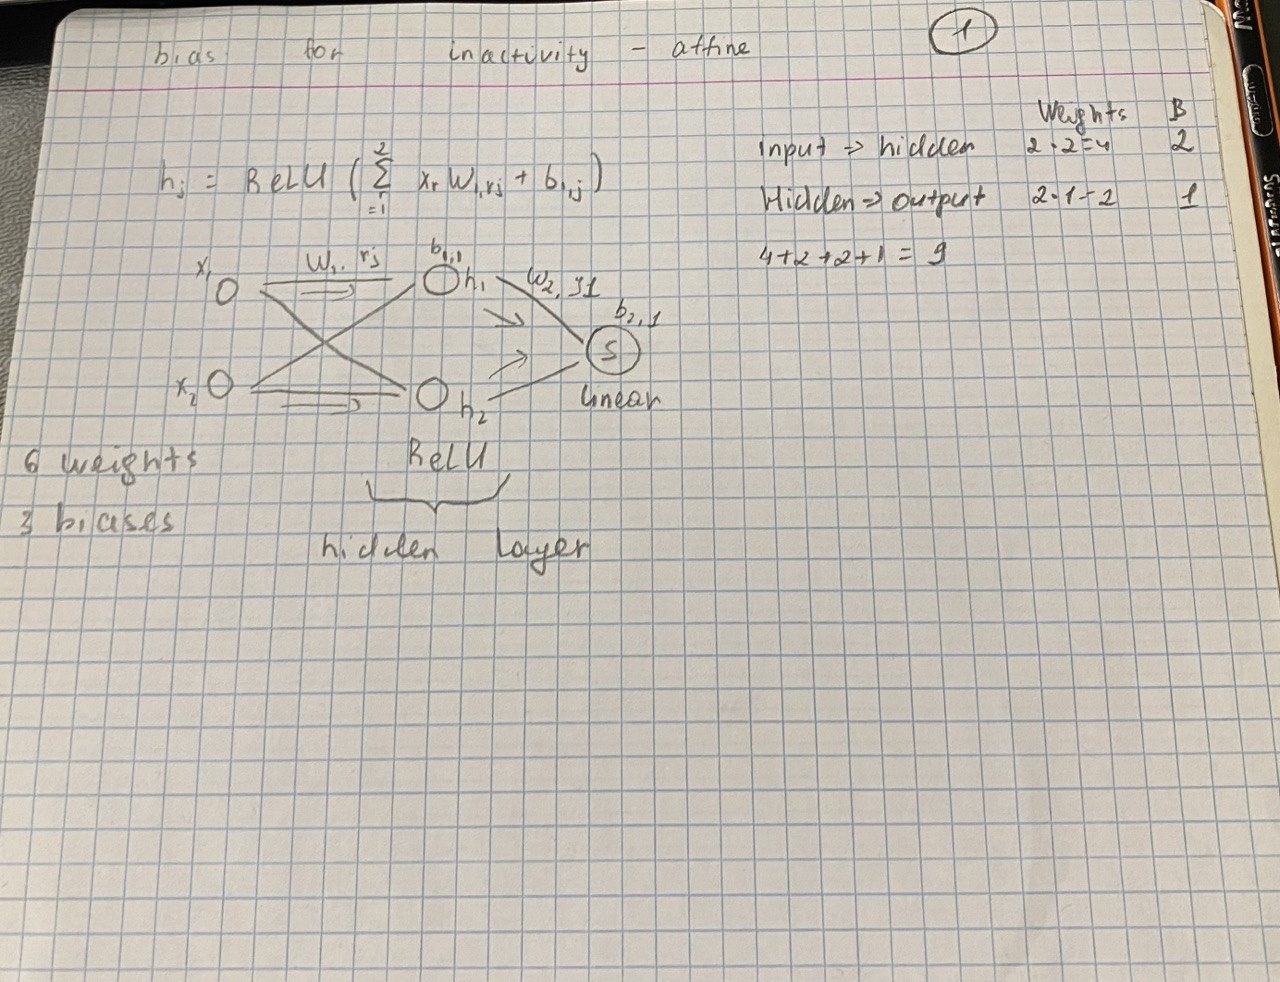


2. Explain why all rows share the same parameters, and why parameter count
doesn’t depend on the number of examples.


answer


### Task 2

#### A. Regression

In [12]:
y = np.array([1,2,4])
y_hat = np.array([0,2,7])


reg_err = y_hat - y

mse = np.mean(reg_err**2)
mae = np.mean(np.abs(reg_err))

print("residuals =", reg_err)
print("MSE =", mse, " MAE =", mae)

assert np.isclose(mse, 10/3) and np.isclose(mae, 4/3)



y_hat2 = np.array([0,2,10])
assert y_hat2.shape == y.shape

reg_err2 = y_hat2 - y
mse2 = np.mean(reg_err2**2)
mae2 = np.mean(np.abs(reg_err2))

print("residuals2 =", reg_err2)
print("MSE =", mse2, " MAE =", mae2)

assert np.isclose(mse2, 37/3) and np.isclose(mae2, 7/3)

residuals = [-1  0  3]
MSE = 3.3333333333333335  MAE = 1.3333333333333333
residuals2 = [-1  0  6]
MSE = 12.333333333333334  MAE = 2.3333333333333335


1. Explain the difference in sensitivity to the larger error – the two losses use different
scales, so a smaller numeric value doesn’t automatically mean “better.”

the largest error doubled from 3 to 6. MAE went up by only 1, about 1.75×, because it grows in a straight line with the error. MSE went up by 9, about 3.7×, because the error is squared: 3² = 9 became 6² = 36. That means one large error dominates MSE, so MSE is much more sensitive to outliers. MSE is also in squared units (like meters²) while MAE is in the target's own units (like meters). So MAE being smaller than MSE here doesn't mean it's "better". The two numbers are on different scales and shouldn't be compared directly

#### B. Binary Classification

In [15]:
y = np.array([1,0])
p_A = np.array([0.8,0.2])
p_B = np.array([0.6,0.4])

for name, p in [("Model A"),p_A], [("Model B"), p_B]:
    assert p.shape == y.shape
    bce = -np.mean(y*np.log(p) + (1-y) * np.log(1-p))
    classes = (p > 0.5).astype(int)
    acc = (classes == y).mean()
    print(f"{name}: BCE = {bce:.4f}  classes = {classes}  accuracy = {acc}")

assert np.isclose(-np.mean(y*np.log(p_A) + (1-y)*np.log(1-p_A)), -np.log(0.8))   
assert np.isclose(-np.mean(y*np.log(p_B) + (1-y)*np.log(1-p_B)), -np.log(0.6))   

Model A: BCE = 0.2231  classes = [1 0]  accuracy = 1.0
Model B: BCE = 0.5108  classes = [1 0]  accuracy = 1.0


1. Explain how the accuracies can agree while the BCE values differ.


accuracy only checks which side of 0.5 each prediction falls on. Both models get both examples right, so they tie. BCE also measures how confident each correct answer was. Model A gives 0.8 to the true class, while Model B only gives 0.6, so B is penalized more. If you fed the thresholded classes (0 or 1) into BCE, all that confidence information would be lost, and a wrong class would give ln(0), which is infinite.

#### C. Multiclass